In [14]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [6]:
DESTINO = Path.cwd().parents[0] / "dataset" / "dataset_bloqueos"
"""
Transofrmaciones 
Redimenciona
voltea
Rota
Cambia color alearorio
Conversion a tensor
Normaliza
"""
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10), # rotacion de 10 y -10 grados
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # varia brillo y contraste en 20 %
    transforms.ToTensor(), # ResNet valores con los que fueron entrenados y los que espera
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# Sin augmentacion para validar la imagen en el test
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # valores de ResNet que se espera
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(DESTINO / "train", transform=train_tf)
val_ds   = datasets.ImageFolder(DESTINO / "val", transform=val_tf)
test_ds  = datasets.ImageFolder(DESTINO / "test", transform=val_tf)

print("Clases:", train_ds.classes)  # debería salir ['bloqueo', 'no_bloqueo']
print(f"train={len(train_ds)} | val={len(val_ds)} | test={len(test_ds)}")
 # organizacion de los datos en lotes de tamaño 32 mezclando
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=32, num_workers=2)


Clases: ['bloqueo', 'no_bloqueo']
train=3846 | val=555 | test=560


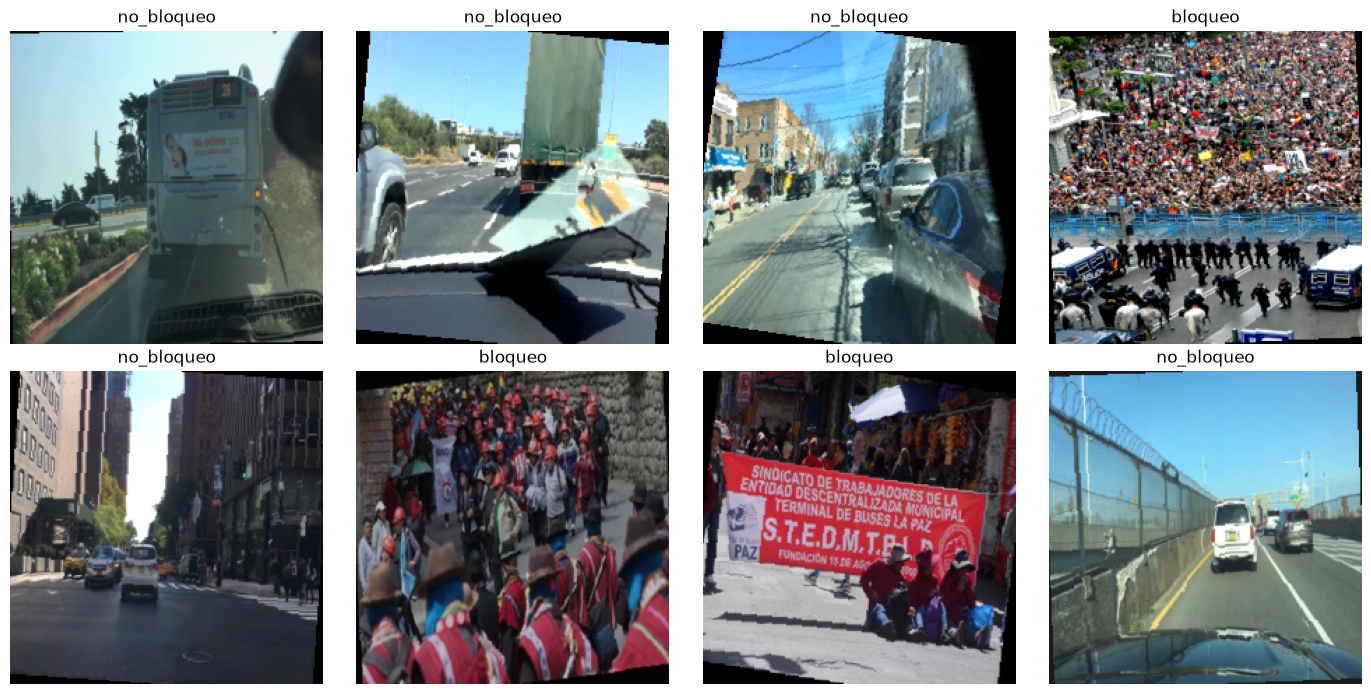

In [9]:
# Tomamos un lote (batch) del train_loader
imgs, labels = next(iter(train_loader))

# Como las imágenes están normalizadas, hay que "desnormalizar" para verlas con colores reales
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def desnormalizar(img_tensor):
    img = img_tensor.numpy().transpose((1, 2, 0))  # de (C,H,W) a (H,W,C)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# Mostramos las primeras 8 imágenes del lote
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
clases = train_ds.classes  # ['bloqueo', 'no_bloqueo']

for i, ax in enumerate(axes.flat):
    img = desnormalizar(imgs[i])
    ax.imshow(img)
    ax.set_title(clases[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Congelamos todas las capas del backbone (el "conocimiento" preentrenado de ImageNet)
# Solo vamos a entrenar la última capa, la que decide bloqueo/no_bloqueo
for param in model.parameters():
    param.requires_grad = False

# Reemplazamos la capa final (originalmente clasifica 1000 clases de ImageNet)
# por una nueva capa que clasifica solo 2 (bloqueo / no_bloqueo)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()  # función de pérdida estándar para clasificación
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)  # solo optimiza la capa nueva

Usando: cpu


In [24]:
import torch
print("PyTorch versión:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA compilado en PyTorch:", torch.version.cuda)

PyTorch versión: 2.12.1+cu130
CUDA disponible: False
CUDA compilado en PyTorch: 13.0


In [17]:
import copy
import time

n_epochs = 10
best_val_acc = 0.0
best_model_weights = None

for epoch in range(n_epochs):
    start = time.time()

    # --- Entrenamiento ---
    model.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_ds)

    # --- Validación ---
    model.eval()
    correct, total = 0, 0
    val_loss = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_loss /= len(val_ds)
    val_acc = correct / total

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{n_epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | tiempo={elapsed:.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())

print(f"\nMejor val_acc: {best_val_acc:.4f}")
model.load_state_dict(best_model_weights)
torch.save(model.state_dict(), "mejor_modelo_bloqueos.pth")

Epoch 1/10 | train_loss=0.3638 | val_loss=0.2004 | val_acc=0.9243 | tiempo=145.6s
Epoch 2/10 | train_loss=0.2150 | val_loss=0.1564 | val_acc=0.9459 | tiempo=129.6s
Epoch 3/10 | train_loss=0.1864 | val_loss=0.1414 | val_acc=0.9495 | tiempo=127.8s
Epoch 4/10 | train_loss=0.1778 | val_loss=0.1211 | val_acc=0.9640 | tiempo=125.8s
Epoch 5/10 | train_loss=0.1669 | val_loss=0.1144 | val_acc=0.9622 | tiempo=127.1s
Epoch 6/10 | train_loss=0.1378 | val_loss=0.1155 | val_acc=0.9622 | tiempo=118.3s
Epoch 7/10 | train_loss=0.1480 | val_loss=0.1049 | val_acc=0.9640 | tiempo=117.0s
Epoch 8/10 | train_loss=0.1579 | val_loss=0.1151 | val_acc=0.9586 | tiempo=117.6s
Epoch 9/10 | train_loss=0.1410 | val_loss=0.1259 | val_acc=0.9604 | tiempo=115.3s
Epoch 10/10 | train_loss=0.1404 | val_loss=0.0950 | val_acc=0.9730 | tiempo=115.4s

Mejor val_acc: 0.9730


In [18]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
todas_preds = []
todas_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        preds = out.argmax(1)
        todas_preds.extend(preds.cpu().numpy())
        todas_labels.extend(labels.cpu().numpy())

todas_preds = np.array(todas_preds)
todas_labels = np.array(todas_labels)

# Accuracy general
acc = (todas_preds == todas_labels).mean()
print(f"Accuracy en test: {acc:.4f}\n")

# Reporte detallado: precision, recall, F1 por clase
print(classification_report(todas_labels, todas_preds, target_names=test_ds.classes))

Accuracy en test: 0.9571

              precision    recall  f1-score   support

     bloqueo       0.97      0.92      0.95       226
  no_bloqueo       0.95      0.98      0.96       334

    accuracy                           0.96       560
   macro avg       0.96      0.95      0.96       560
weighted avg       0.96      0.96      0.96       560



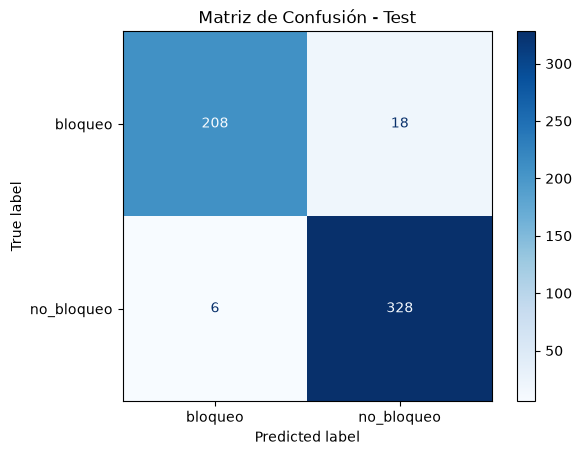

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(todas_labels, todas_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_ds.classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión - Test")
plt.show()

In [20]:
from PIL import Image

def predecir_imagen(ruta_imagen, model, transform, clases, device):
    img = Image.open(ruta_imagen).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(device)  # agrega dimensión de batch

    model.eval()
    with torch.no_grad():
        out = model(img_t)
        probs = torch.softmax(out, dim=1)
        pred_idx = probs.argmax(1).item()
        confianza = probs[0][pred_idx].item()

    print(f"Predicción: {clases[pred_idx]} (confianza: {confianza:.2%})")
    return clases[pred_idx], confianza

# Ejemplo de uso
predecir_imagen("/home/jessihdd/SCESI/CursoIA/Deteccion-Bloqueos/images.jpeg", model, val_tf, test_ds.classes, device)

Predicción: bloqueo (confianza: 99.98%)


('bloqueo', 0.999762237071991)

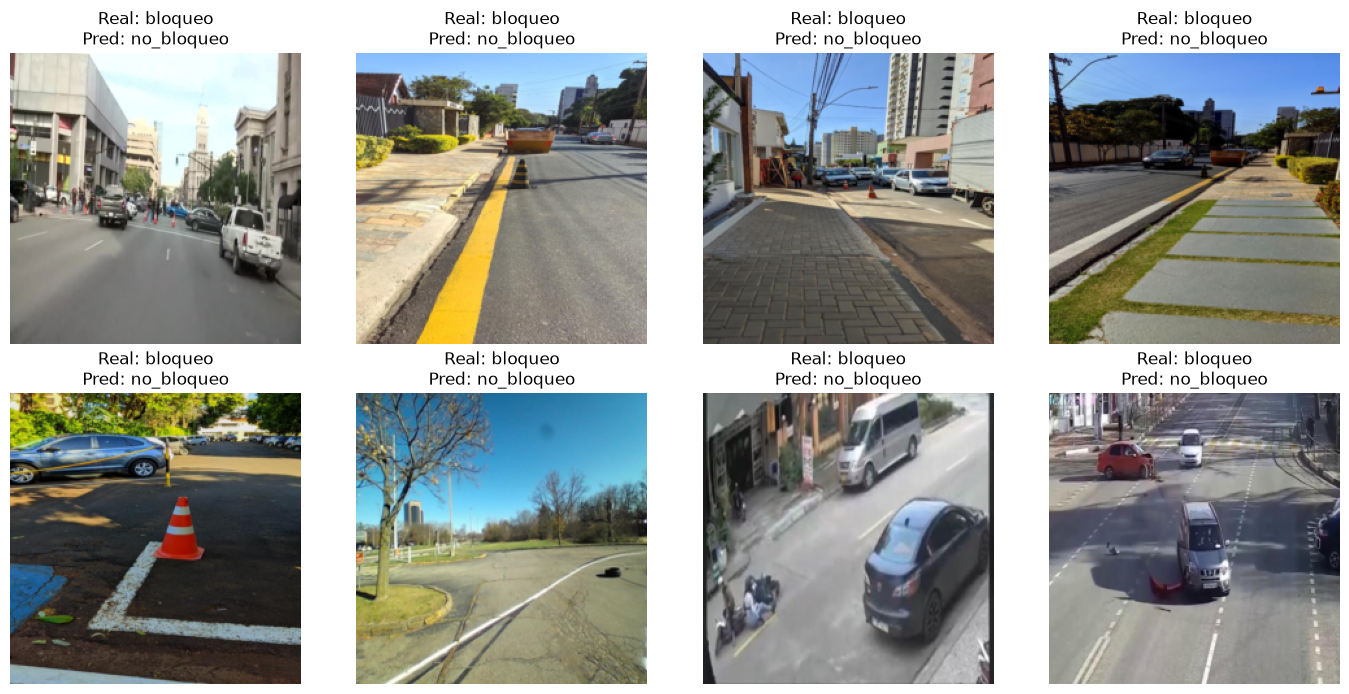

In [22]:
import matplotlib.pyplot as plt
import numpy as np

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def desnormalizar(img_tensor):
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    return np.clip(img, 0, 1)

# Recolectar algunos errores
model.eval()
errores = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs_dev, labels_dev = imgs.to(device), labels.to(device)
        out = model(imgs_dev)
        preds = out.argmax(1)
        for i in range(len(labels)):
            if preds[i] != labels_dev[i]:
                errores.append((imgs[i], labels[i].item(), preds[i].item()))
        if len(errores) >= 8:
            break

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < len(errores):
        img, real, pred = errores[i]
        ax.imshow(desnormalizar(img))
        ax.set_title(f"Real: {test_ds.classes[real]}\nPred: {test_ds.classes[pred]}")
        ax.axis("off")
plt.tight_layout()
plt.show()